In [1]:
import zipfile
import pandas as pd

In [2]:
zf = zipfile.ZipFile("C://Users/nachiket/Downloads/beta_lactamase_CHEMBL29.zip","r")

df = pd.concat((pd.read_csv(zf.open(f)) for f in zf.namelist()))

In [3]:
df

,molecule_chembl_id,canonical_smiles,standard_relation,standard_value,standard_units,standard_type,pchembl_value,target_pref_name,bao_label
0,CHEMBL1730,CO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)O)=C(COC(C)...,=,10.0,/mM/s,Kcat/Km,NaN,Gil1,assay format
1,CHEMBL996,CO[C@@]1(NC(=O)Cc2cccs2)C(=O)N2C(C(=O)O)=C(COC...,NaN,NaN,NaN,Kcat/Km,NaN,Gil1,assay format
2,CHEMBL617,CC(=O)OCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)Cc3ccc...,=,598.0,/mM/s,Kcat/Km,NaN,Gil1,assay format
3,CHEMBL702,CCN1CCN(C(=O)N[C@@H](C(=O)N[C@@H]2C(=O)N3[C@@H...,=,3400.0,/mM/s,Kcat/Km,NaN,Gil1,assay format
4,CHEMBL1449,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](C(=O)O)c3ccsc3...,=,10000.0,/mM/s,Kcat/Km,NaN,Gil1,assay format
...,...,...,...,...,...,...,...,...,...
13,CHEMBL561555,COC(=O)CC(N)(CC(=O)OC)C(=O)OCc1ccccc1,NaN,NaN,NaN,Inhibition,NaN,Beta-lactamase VIM-4,single protein format
14,CHEMBL561821,NC(CC(=O)OCc1ccccc1)(CC(=O)OCc1ccccc1)C(=O)OCc...,NaN,NaN,NaN,Inhibition,NaN,Beta-lactamase VIM-4,single protein format
15,CHEMBL561896,COC(=O)CC(CC(=O)OC)(NC(=O)Cc1ccccc1)C(=O)OC,NaN,NaN,NaN,Inhibition,NaN,Beta-lactamase VIM-4,single protein format
16,CHEMBL563044,COC(=O)C(CC(=O)OCc1ccccc1)(CC(=O)OCc1ccccc1)NC...,NaN,NaN,NaN,Inhibition,NaN,Beta-lactamase VIM-4,single protein format


In [4]:
# bar plot of missing vs non missing data

import matplotlib.pyplot as plt

In [5]:
# data 
missing = df.pchembl_value.isnull().sum()

In [6]:
nonmissing = df.pchembl_value.notnull().sum()

In [7]:
x = ['Missing', 'Non-missing']
y = [missing, nonmissing]

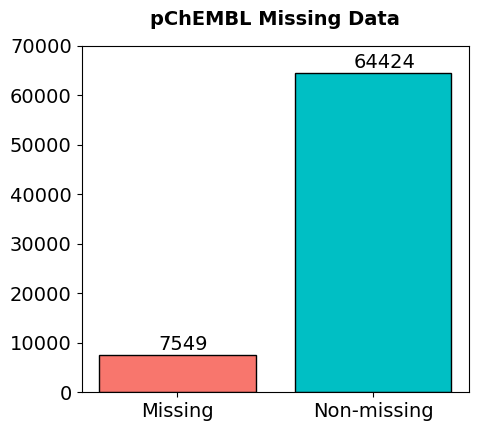

In [8]:
# setup plot
fig, ax = plt.subplots()

# make bar plot
p = ax.bar(x, y, color = ['#F8766D', '#00BFC4'], ec = 'black')

ax.set_title('pChEMBL Missing Data', fontsize = 14, fontweight = 'bold', pad = 15)
# ax.set_xticklabels(x, fontweight='bold')

ax.set_ylim(0, 70000)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)

# label above bar
for index, data in enumerate(y):
    plt.text(x=index-0.1, y=data+1000, s=f"{data}", fontdict=dict(fontsize=14))

fig.set_size_inches(5, 4.5)
plt.show()

In [9]:
# non-missing data with pChEMBL value
df2 = df[df.pchembl_value.notnull()]
df

,molecule_chembl_id,canonical_smiles,standard_relation,standard_value,standard_units,standard_type,pchembl_value,target_pref_name,bao_label
0,CHEMBL1730,CO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)O)=C(COC(C)...,=,10.0,/mM/s,Kcat/Km,NaN,Gil1,assay format
1,CHEMBL996,CO[C@@]1(NC(=O)Cc2cccs2)C(=O)N2C(C(=O)O)=C(COC...,NaN,NaN,NaN,Kcat/Km,NaN,Gil1,assay format
2,CHEMBL617,CC(=O)OCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)Cc3ccc...,=,598.0,/mM/s,Kcat/Km,NaN,Gil1,assay format
3,CHEMBL702,CCN1CCN(C(=O)N[C@@H](C(=O)N[C@@H]2C(=O)N3[C@@H...,=,3400.0,/mM/s,Kcat/Km,NaN,Gil1,assay format
4,CHEMBL1449,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](C(=O)O)c3ccsc3...,=,10000.0,/mM/s,Kcat/Km,NaN,Gil1,assay format
...,...,...,...,...,...,...,...,...,...
13,CHEMBL561555,COC(=O)CC(N)(CC(=O)OC)C(=O)OCc1ccccc1,NaN,NaN,NaN,Inhibition,NaN,Beta-lactamase VIM-4,single protein format
14,CHEMBL561821,NC(CC(=O)OCc1ccccc1)(CC(=O)OCc1ccccc1)C(=O)OCc...,NaN,NaN,NaN,Inhibition,NaN,Beta-lactamase VIM-4,single protein format
15,CHEMBL561896,COC(=O)CC(CC(=O)OC)(NC(=O)Cc1ccccc1)C(=O)OC,NaN,NaN,NaN,Inhibition,NaN,Beta-lactamase VIM-4,single protein format
16,CHEMBL563044,COC(=O)C(CC(=O)OCc1ccccc1)(CC(=O)OCc1ccccc1)NC...,NaN,NaN,NaN,Inhibition,NaN,Beta-lactamase VIM-4,single protein format


In [10]:
df2.groupby('molecule_chembl_id').mean(numeric_only=True)# mean() only not working

,standard_value,pchembl_value
molecule_chembl_id,,
CHEMBL1018,316.200000,6.500000
CHEMBL1024,11220.200000,4.950000
CHEMBL1028,2818.400000,5.550000
CHEMBL1036,39.800000,7.400000
CHEMBL104,27500.000000,4.580000
...,...,...
CHEMBL97643,11220.200000,4.950000
CHEMBL977,631.000000,6.200000
CHEMBL98406,63095.700000,4.200000


In [11]:
df2.groupby('molecule_chembl_id').std(numeric_only=True)

,standard_value,pchembl_value
molecule_chembl_id,,
CHEMBL1018,NaN,NaN
CHEMBL1024,NaN,NaN
CHEMBL1028,NaN,NaN
CHEMBL1036,NaN,NaN
CHEMBL104,10606.601718,0.169706
...,...,...
CHEMBL97643,NaN,NaN
CHEMBL977,NaN,NaN
CHEMBL98406,NaN,NaN


In [12]:
df3 = df2.groupby('molecule_chembl_id').std(numeric_only=True)
df3[(df3.pchembl_value < 2) & (df3.pchembl_value == pd.NA)]

,standard_value,pchembl_value
molecule_chembl_id,,


In [13]:
import numpy as np
df3 = df2.groupby('molecule_chembl_id').std(numeric_only=True)
df3[df3.pchembl_value == np.nan]

,standard_value,pchembl_value
molecule_chembl_id,,


In [14]:
print('Number of unique ChEMBL ID: ', str(len(df.molecule_chembl_id.unique())))
print('Total  number of ChEMBL ID: ', str(len(df)))
print('Number of missing ChEMBL ID: ', str(df.molecule_chembl_id.isnull().sum()))

Number of unique ChEMBL ID:  64436
Total  number of ChEMBL ID:  71973
Number of missing ChEMBL ID:  0


In [15]:
import matplotlib.pyplot as plt

unique = len(df.molecule_chembl_id.unique())
not_unique = len(df) - unique

x = ['Unique', 'Redundant']
y = [unique, not_unique]

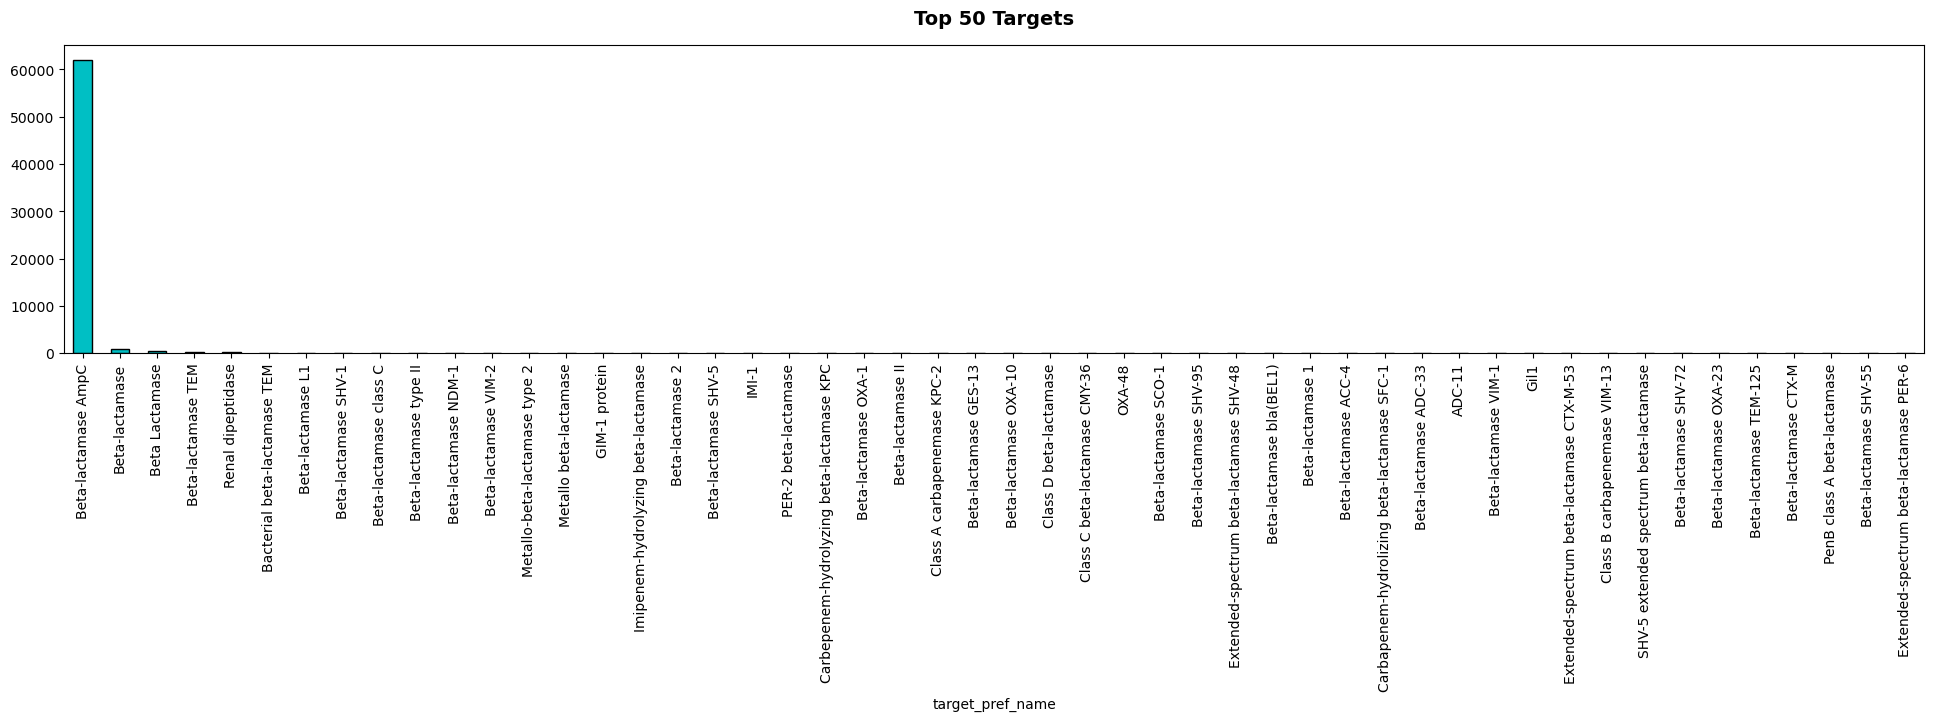

In [16]:
df2.target_pref_name.value_counts()[0:50].plot.bar(figsize=(24,4), color='#00BFC4', ec='black')

plt.title('Top 50 Targets', fontsize=14, fontweight='black', pad=15)
plt.show()

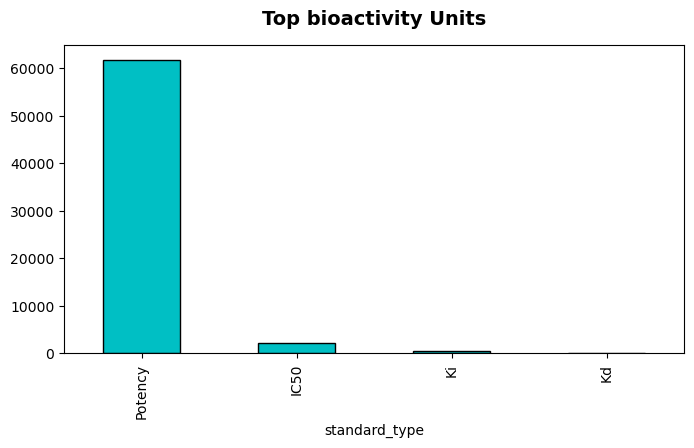

In [17]:
# top 10 bioactivity unite
df2.standard_type.value_counts()[:10].plot.bar(figsize=(8,4), color='#00BFC4', ec='black')

plt.title('Top bioactivity Units', fontsize = 14, fontweight = 'black', pad=15)
plt.show()

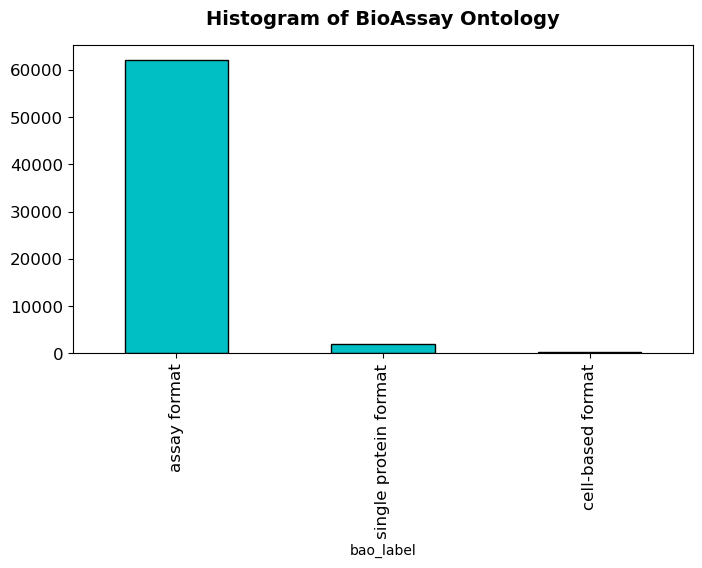

In [18]:
bao_labels = df2.bao_label.value_counts()
bao_labels.plot.bar(figsize=(8,4), color ='#00BFC4', ec='black')

plt.title('Histogram of BioAssay Ontology', fontsize = 14, fontweight = 'black', pad =15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [19]:
bao_labels

bao_label
assay format             62068
single protein format     2047
cell-based format          309
Name: count, dtype: int64

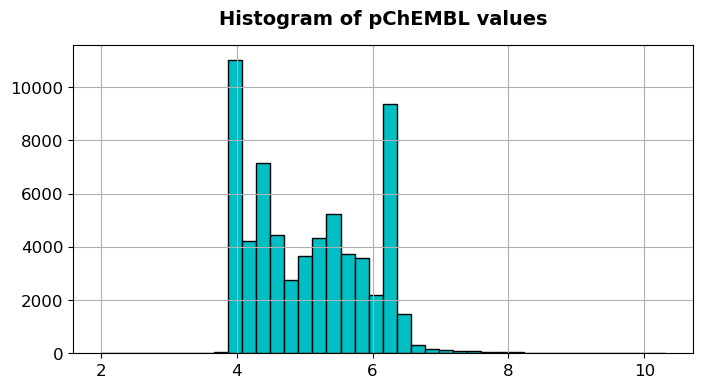

In [20]:
df2.pchembl_value.hist(bins=40, figsize=(8,4), color='#00BFC4', ec='black')

plt.title('Histogram of pChEMBL values', fontsize=14, fontweight='black', pad=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

pCHEMBL values < 5 == 'Inactive'
pCHEMBL values > 6 == 'Active'
pCHEMBL values 5-6 == 'Intermediate'